# Spin-Orbit Unmixing using jaxinv (Type 2)

last update: 5/8 (2025) Hajime Kawahara

In this tutorial, we use the Type 2 Bayesian linear inverse problem solver from jaxinv to estimate maps and spectra from multiband time-series data.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

Note: It is known that the current implementation does not work properly unless 64-bit mode is enabled.

In [2]:
from jax import config
config.update("jax_enable_x64", True)


In [3]:
import numpy as np
import healpy as hp
import matplotlib
from sot.core import sepmat
from sot.core.weight import compute_weight 



In [4]:
fontsize=16
matplotlib.rcParams.update({'font.size':fontsize})
np.random.seed(53)

#set geometry                                                               
inc=45.0/180.0*np.pi
Thetaeq=np.pi
zeta=23.4/180.0*np.pi
Pspin=23.9344699/24.0 #Pspin: a sidereal day                                
wspin=2*np.pi/Pspin
Porb=365.242190402
worb=2*np.pi/Porb                                                          \

Ni=256
obst=np.linspace(0.0,Porb,Ni)

{'ocean': 0, 'desert': 100, 'veg': 30}


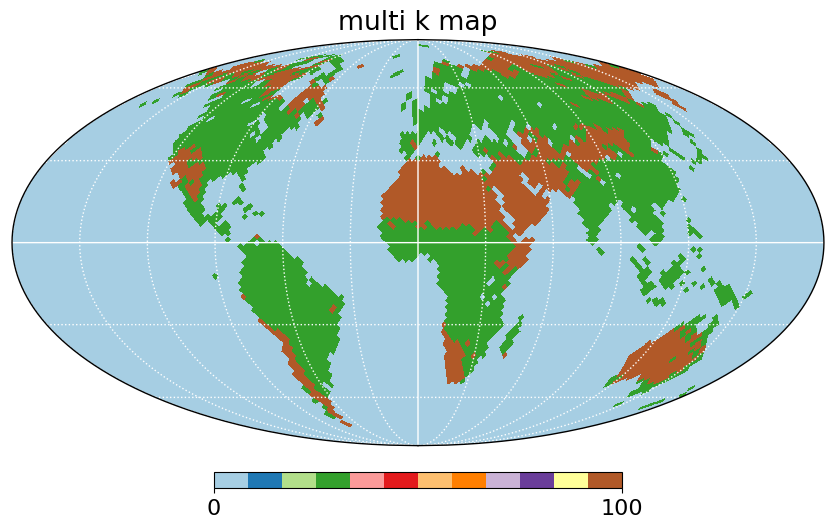

In [5]:
from sot.io.load_data import get_data_filepath
from sot.io.load_data import load_multi_kmap
import matplotlib.pyplot as plt

#multi k map
file_path = get_data_filepath("cmap3class.npz")
cmap, nclass, npix, nside, dict_class = load_multi_kmap(file_path)
Nk = len(dict_class)
print(dict_class)

hp.mollview(cmap, title="multi k map",flip="geo",cmap=plt.cm.Paired)
hp.graticule(color="white")


In [9]:
from sot.io.load_data import load_refdata

refdict = load_refdata()
reference_surfaces = {"ocean": "water", "desert": "soil", "veg": "vegetation"}
bands = [
    [0.4, 0.45],
    [0.45, 0.5],
    [0.5, 0.55],
    [0.55, 0.6],
    [0.6, 0.65],
    [0.65, 0.7],
    [0.7, 0.75],
    [0.75, 0.8],
    [0.8, 0.85],
    [0.85, 0.9],
]

from sot.core.toymap import generate_multiband_map
map_matrix, spectral_matrix = generate_multiband_map(
    cmap,
    dict_class,
    refdict,
    reference_surfaces,
    bands,
    onsky=True,
    sky=refdict["clear_sky"],
)

Nl = len(bands)
print(Nl)

10


In [10]:
import jax.numpy as jnp
from jaxinv.model.linear import type2
# geometric weight
Thetav = worb * obst
Phiv = np.mod(wspin * obst, 2 * np.pi)
WI, WV = compute_weight(nside, zeta, inc, Thetaeq, Thetav, Phiv)
W = jnp.array(WV[:, :] * WI[:, :])
map_matrix = jnp.array(map_matrix)
spectral_matrix = jnp.array(spectral_matrix)
# Light curve

#lc = jnp.sum(W * movmap, axis=1)
lc = type2(W, spectral_matrix, map_matrix)
noiselevel = 0.001
sigma = noiselevel * np.mean(lc)
noise = sigma * np.random.normal(0.0, 1.0, np.shape(lc))
lc = lc + noise

In [11]:
import jax.numpy as jnp
from jaxinv.bayes.gpkernel import rbf
from jaxinv.bayes.gpkernel import matern32
from sot.plot.plotdymap import plotseqmap
from jaxinv.bayes.meanmap import meanmap_inverse_type2

tau = 180.0
gamma = 10.0 / 180.0 * np.pi 
separation_matrix = sepmat.calc_sepmatrix(nside)
KS = rbf(separation_matrix, gamma)

#map k-direction covariance
KX = np.eye(Nk)

alpha = 0.25
Pid = jnp.eye(Ni*Nl) * sigma**-2 #when using jnp.eye Matrix becomes singular when x32
    
Mast = meanmap_inverse_type2(W, spectral_matrix, KS, KX, alpha, Pid, lc)


TypeError: dot_general requires contracting dimensions to have the same shape, got (2560,) and (256,).